# Week 4 - Day 18

# Regularization: Ridge, Lasso & ElasticNet

---

## Objective

The objective of this notebook is to understand how regularization techniques help prevent overfitting in Machine Learning models.

In this notebook, we will learn:

- Overfitting
- Underfitting
- Bias-Variance Tradeoff
- Ridge Regression
- Lasso Regression
- ElasticNet
- Feature Scaling
- GridSearchCV
- Logistic Regression with Regularization
- Model Comparison
- Algorithm Cheat Sheet

---

# Import Required Libraries

Before building any Machine Learning model, we need to import the required Python libraries.

We will use:

- Pandas → Data Manipulation
- NumPy → Numerical Computation
- Matplotlib → Data Visualization
- Scikit-Learn → Machine Learning Models
- OS → Create folders for outputs

In [1]:
# ==========================================
# Import Libraries
# ==========================================

import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    LogisticRegression
)

from sklearn.metrics import (
    r2_score,
    accuracy_score,
    mean_squared_error
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Create Output Folders

To keep the project organized, we will automatically create two folders:

- images → Stores graphs
- outputs → Stores CSV files and model results

This ensures that our notebook runs successfully even on another computer.

In [2]:
# ==========================================
# Create Required Folders
# ==========================================

os.makedirs("images", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("Folders Created Successfully")

Folders Created Successfully


# Load Dataset

For this task, we are using the **California Housing Dataset** downloaded from Kaggle.

Dataset Link:

https://www.kaggle.com/datasets/camnugent/california-housing-prices

This dataset is used for Regression problems.

Our goal is to predict the **Median House Value** using different housing-related features.

In [3]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("dataset/housing.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# Dataset Information

Let's examine the dataset structure.

This helps us understand:

- Number of rows
- Number of columns
- Data types
- Missing values

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.shape

(20640, 10)

In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


# Check Missing Values

Missing values can negatively affect Machine Learning models.

Let's check whether our dataset contains any missing values.

In [7]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

# Separate Features and Target Variable

Our target variable is:

**median_house_value**

All remaining columns will be used as input features.

# Feature Engineering

Before training Machine Learning models, we need to prepare the dataset.

Our dataset contains one categorical column:

- ocean_proximity

Machine Learning algorithms cannot work directly with text values, so we will convert this column into numerical values using One-Hot Encoding.

After that, we will separate:

- Features (X)
- Target Variable (y)

In [8]:
# ==========================================
# One-Hot Encoding
# ==========================================

df = pd.get_dummies(
    df,
    columns=["ocean_proximity"],
    drop_first=True
)

print("Categorical Feature Encoded Successfully")

df.head()

Categorical Feature Encoded Successfully


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


# Separate Features and Target Variable

The target variable is:

- median_house_value

All remaining columns will be used as input features.

In [9]:
# ==========================================
# Features and Target
# ==========================================

X = df.drop("median_house_value", axis=1)

y = df["median_house_value"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (20640, 12)
Target Shape   : (20640,)


# Train-Test Split

To evaluate our Machine Learning models fairly, we divide the dataset into two parts:

- Training Set (80%)
- Testing Set (20%)

The training data is used to train the model, while the testing data is used to evaluate its performance on unseen data.

In [10]:
# ==========================================
# Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (16512, 12)
Testing Data  : (4128, 12)


# Feature Scaling

Regularization algorithms such as:

- Ridge Regression
- Lasso Regression
- ElasticNet

are highly sensitive to feature scales.

Therefore, we standardize the features using StandardScaler.

This transforms each feature so that:

- Mean = 0
- Standard Deviation = 1

In [11]:
# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed Successfully")

Feature Scaling Completed Successfully


# Visualizing Overfitting and Underfitting

Before learning Regularization, it is important to understand why Regularization is needed.

One common reason is **Overfitting**.

A model that is too simple underfits the data.

A model that is too complex memorizes the training data and overfits.

Below, we visualize this concept using Decision Trees with different depths.

In [12]:
from sklearn.tree import DecisionTreeRegressor

train_scores = []
test_scores = []

depths = range(1, 21)

for depth in depths:

    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

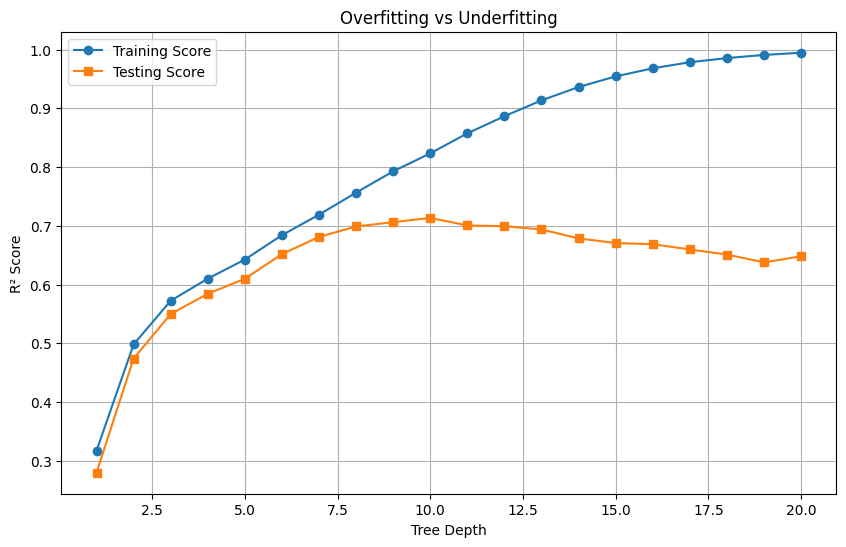

In [13]:
plt.figure(figsize=(10,6))

plt.plot(depths, train_scores, marker="o", label="Training Score")
plt.plot(depths, test_scores, marker="s", label="Testing Score")

plt.xlabel("Tree Depth")
plt.ylabel("R² Score")
plt.title("Overfitting vs Underfitting")

plt.legend()

plt.grid(True)

plt.savefig(
    "images/overfitting_vs_underfitting.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Observation

From the graph we can observe:

- Small tree depth leads to underfitting.
- Large tree depth gives excellent training performance but poor testing performance.
- This gap between training and testing performance indicates overfitting.
- Regularization techniques help reduce this problem by controlling model complexity.

# Observation

From the graph we can observe:

- Small tree depth leads to underfitting.
- Large tree depth gives excellent training performance but poor testing performance.
- This gap between training and testing performance indicates overfitting.
- Regularization techniques help reduce this problem by controlling model complexity.

# Handle Missing Values

The California Housing dataset contains missing values in the **total_bedrooms** column.

Machine Learning algorithms such as:

- Linear Regression
- Ridge Regression
- Lasso Regression
- ElasticNet

cannot work with missing values.

Therefore, we replace missing values with the **median** of the column.

In [15]:
# ==========================================
# Handle Missing Values
# ==========================================

print("Missing Values Before Cleaning")
print(df.isnull().sum())

# Fill missing values only in total_bedrooms
df["total_bedrooms"] = df["total_bedrooms"].fillna(
    df["total_bedrooms"].median()
)

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

Missing Values Before Cleaning
longitude                       0
latitude                        0
housing_median_age              0
total_rooms                     0
total_bedrooms                207
population                      0
households                      0
median_income                   0
median_house_value              0
ocean_proximity_INLAND          0
ocean_proximity_ISLAND          0
ocean_proximity_NEAR BAY        0
ocean_proximity_NEAR OCEAN      0
dtype: int64

Missing Values After Cleaning
longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64


# Prepare Features and Target Variable

Before training our machine learning models, we separate the dataset into:

- Features (X)
- Target Variable (y)

The target variable for this dataset is:

**median_house_value**

In [17]:
# ==========================================
# Features and Target Variable
# ==========================================

# Features
X = df.drop("median_house_value", axis=1)

# Target
y = df["median_house_value"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (20640, 12)
Target Shape   : (20640,)


# Train-Test Split

The dataset is divided into two parts:

- Training Data (80%)
- Testing Data (20%)

The model learns from the training data and is evaluated on the testing data.

In [18]:
# ==========================================
# Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (16512, 12)
Testing Shape  : (4128, 12)


# Feature Scaling

Machine Learning algorithms based on Regularization require scaled features.

Therefore, we standardize the features using StandardScaler.

In [19]:
# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed Successfully")

Feature Scaling Completed Successfully


# Linear Regression

Linear Regression is our baseline model.

Later, we will compare its performance with:

- Ridge Regression
- Lasso Regression
- ElasticNet

In [20]:
# ==========================================
# Linear Regression
# ==========================================

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_r2 = r2_score(y_test, linear_predictions)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))

print("Linear Regression Performance")
print("-" * 40)
print(f"R² Score : {linear_r2:.4f}")
print(f"RMSE     : {linear_rmse:.2f}")

Linear Regression Performance
----------------------------------------
R² Score : 0.6254
RMSE     : 70060.52


# Ridge Regression

Ridge Regression is an extension of Linear Regression that uses **L2 Regularization**.

Instead of allowing very large coefficient values, Ridge adds a penalty term to the loss function.

This helps reduce overfitting and improves the model's ability to generalize to unseen data.

The regularization strength is controlled by the **alpha** parameter.

In [22]:
# ==========================================
# Ridge Regression
# ==========================================

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

ridge_predictions = ridge_model.predict(X_test)

ridge_r2 = r2_score(y_test, ridge_predictions)

ridge_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_predictions)
)

print("Ridge Regression Performance")
print("-" * 40)
print(f"R² Score : {ridge_r2:.4f}")
print(f"RMSE     : {ridge_rmse:.2f}")

Ridge Regression Performance
----------------------------------------
R² Score : 0.6255
RMSE     : 70057.42


# Lasso Regression

Lasso Regression uses **L1 Regularization**.

Unlike Ridge Regression, Lasso can reduce some feature coefficients exactly to zero.

This makes Lasso useful for feature selection, especially when working with datasets that contain many irrelevant features.

In [23]:
# ==========================================
# Lasso Regression
# ==========================================

lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)

lasso_predictions = lasso_model.predict(X_test)

lasso_r2 = r2_score(y_test, lasso_predictions)

lasso_rmse = np.sqrt(
    mean_squared_error(y_test, lasso_predictions)
)

print("Lasso Regression Performance")
print("-" * 40)
print(f"R² Score : {lasso_r2:.4f}")
print(f"RMSE     : {lasso_rmse:.2f}")

Lasso Regression Performance
----------------------------------------
R² Score : 0.6254
RMSE     : 70060.45


# ElasticNet

ElasticNet combines the strengths of both Ridge (L2) and Lasso (L1) Regularization.

It performs coefficient shrinkage while also allowing feature selection.

The **l1_ratio** parameter controls the balance between Ridge and Lasso penalties.

In [24]:
# ==========================================
# ElasticNet
# ==========================================

elastic_model = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5,
    random_state=42
)

elastic_model.fit(X_train, y_train)

elastic_predictions = elastic_model.predict(X_test)

elastic_r2 = r2_score(y_test, elastic_predictions)

elastic_rmse = np.sqrt(
    mean_squared_error(y_test, elastic_predictions)
)

print("ElasticNet Performance")
print("-" * 40)
print(f"R² Score : {elastic_r2:.4f}")
print(f"RMSE     : {elastic_rmse:.2f}")

ElasticNet Performance
----------------------------------------
R² Score : 0.6234
RMSE     : 70244.97


# Model Performance Comparison

Now that all four regression models have been trained, we compare their performance using:

- R² Score
- RMSE (Root Mean Squared Error)

A higher R² score indicates better prediction accuracy, while a lower RMSE indicates lower prediction error.

In [25]:
# ==========================================
# Performance Comparison
# ==========================================

comparison_df = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "ElasticNet"
    ],

    "R2 Score": [
        linear_r2,
        ridge_r2,
        lasso_r2,
        elastic_r2
    ],

    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        elastic_rmse
    ]

})

comparison_df

,Model,R2 Score,RMSE
0,Linear Regression,0.625424,70060.521845
1,Ridge Regression,0.625457,70057.416870
2,Lasso Regression,0.625425,70060.454594
3,ElasticNet,0.623449,70244.965085


In [26]:
# Save Comparison Table

comparison_df.to_csv(
    "outputs/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


# Compare Model Coefficients

Regularization techniques affect the coefficients of the model.

- Linear Regression → No Regularization
- Ridge Regression → Shrinks coefficients
- Lasso Regression → Shrinks coefficients and can make some coefficients exactly zero
- ElasticNet → Combination of Ridge and Lasso

Let's compare the coefficients learned by each model.

In [27]:
# ==========================================
# Compare Model Coefficients
# ==========================================

coefficient_df = pd.DataFrame({

    "Feature": X.columns,

    "Linear": linear_model.coef_,

    "Ridge": ridge_model.coef_,

    "Lasso": lasso_model.coef_,

    "ElasticNet": elastic_model.coef_

})

coefficient_df.head()

,Feature,Linear,Ridge,Lasso,ElasticNet
0,longitude,-53826.648016,-53713.651593,-53823.758865,-22441.644774
1,latitude,-54415.696144,-54298.400415,-54412.794624,-22000.370572
2,housing_median_age,13889.866189,13890.472329,13889.799421,13342.930880
3,total_rooms,-13094.251162,-13058.643741,-13092.146766,52.314988
4,total_bedrooms,43068.181842,42978.328403,43065.901923,21025.599743


In [28]:
# Save coefficient comparison

coefficient_df.to_csv(
    "outputs/model_coefficients.csv",
    index=False
)

print("Coefficient comparison saved successfully.")

Coefficient comparison saved successfully.


# Save Individual Model Coefficients

For better project organization, we save the coefficients of each model separately.

These files can later be used for analysis and comparison.

In [29]:
# Ridge Coefficients

ridge_df = pd.DataFrame({

    "Feature": X.columns,
    "Coefficient": ridge_model.coef_

})

ridge_df.to_csv(
    "outputs/ridge_coefficients.csv",
    index=False
)

In [30]:
# Lasso Coefficients

lasso_df = pd.DataFrame({

    "Feature": X.columns,
    "Coefficient": lasso_model.coef_

})

lasso_df.to_csv(
    "outputs/lasso_coefficients.csv",
    index=False
)

In [31]:
# ElasticNet Coefficients

elastic_df = pd.DataFrame({

    "Feature": X.columns,
    "Coefficient": elastic_model.coef_

})

elastic_df.to_csv(
    "outputs/elasticnet_coefficients.csv",
    index=False
)

print("Individual coefficient files saved successfully.")

Individual coefficient files saved successfully.


# Ridge Regularization Path

The Regularization Path shows how Ridge Regression coefficients change as the value of **alpha** increases.

As alpha increases:

- Coefficients become smaller.
- Model complexity decreases.
- Overfitting is reduced.

In [32]:
# ==========================================
# Ridge Regularization Path
# ==========================================

alphas = [0.01, 0.1, 1, 10, 100]

ridge_coefficients = []

for alpha in alphas:

    ridge = Ridge(alpha=alpha)

    ridge.fit(X_train, y_train)

    ridge_coefficients.append(ridge.coef_)

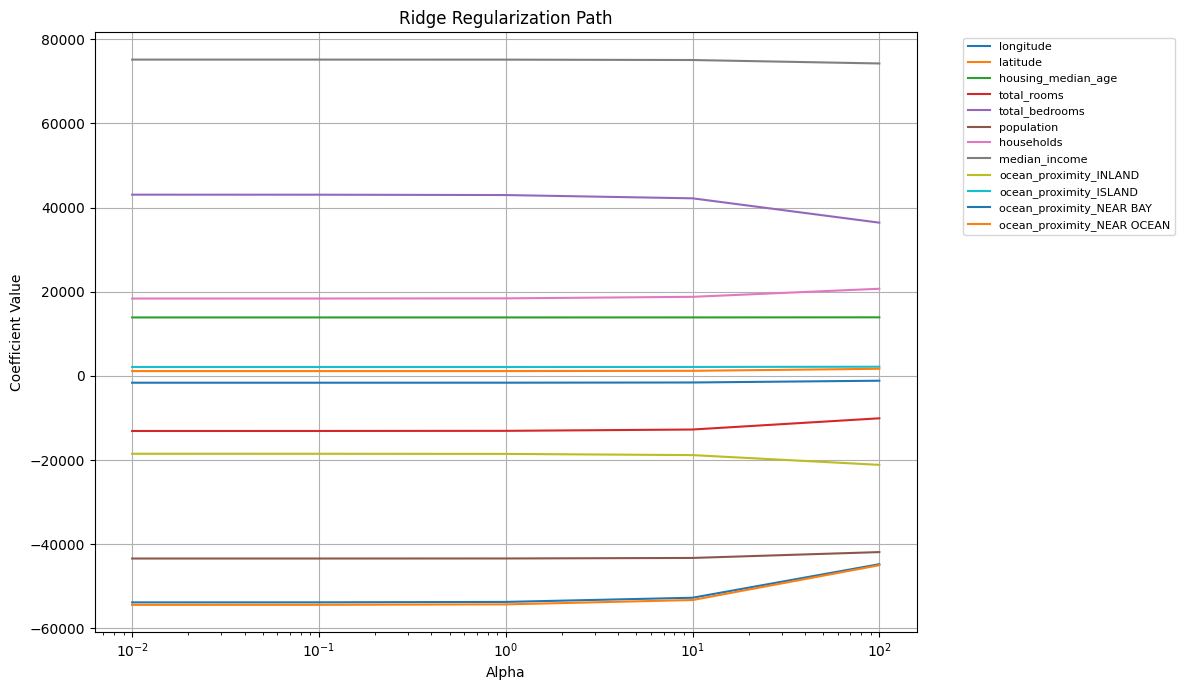

In [33]:
plt.figure(figsize=(12,7))

for i in range(len(X.columns)):

    plt.plot(
        alphas,
        [coef[i] for coef in ridge_coefficients],
        label=X.columns[i]
    )

plt.xscale("log")

plt.xlabel("Alpha")

plt.ylabel("Coefficient Value")

plt.title("Ridge Regularization Path")

plt.grid(True)

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    "images/ridge_regularization_path.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Lasso Regularization Path

Lasso Regression behaves differently from Ridge Regression.

As alpha increases:

- More coefficients become exactly zero.
- Feature selection occurs automatically.
- The model becomes simpler.

In [34]:
# ==========================================
# Lasso Regularization Path
# ==========================================

lasso_coefficients = []

for alpha in alphas:

    lasso = Lasso(alpha=alpha)

    lasso.fit(X_train, y_train)

    lasso_coefficients.append(lasso.coef_)

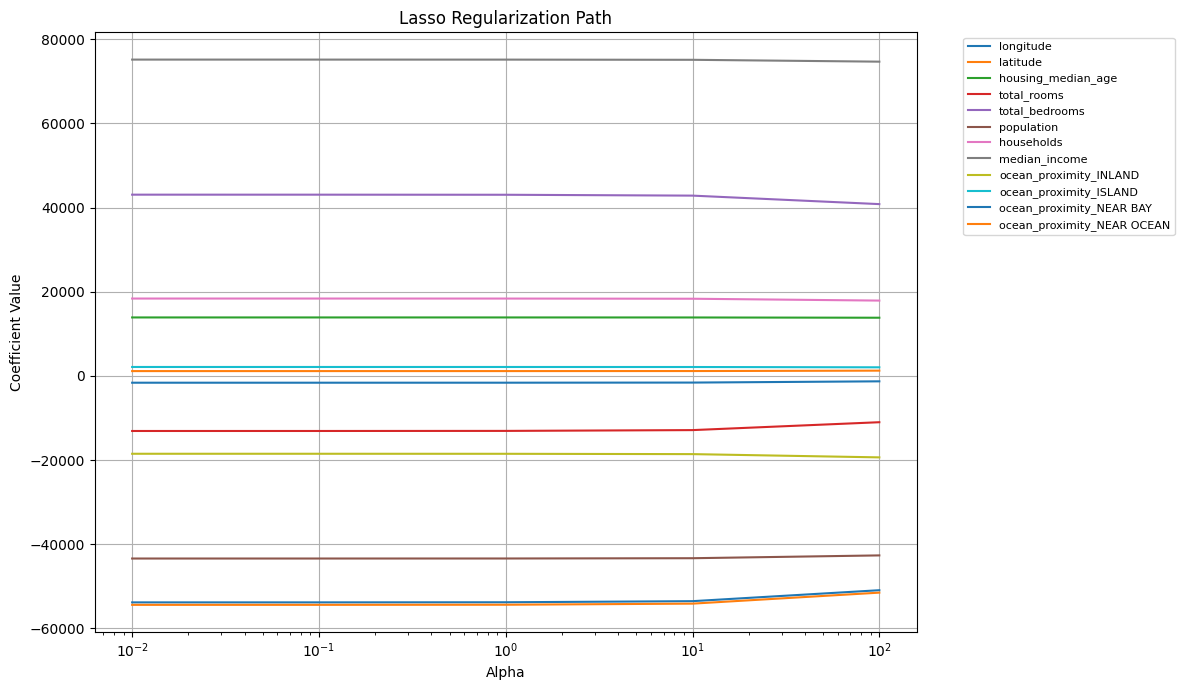

In [35]:
plt.figure(figsize=(12,7))

for i in range(len(X.columns)):

    plt.plot(
        alphas,
        [coef[i] for coef in lasso_coefficients],
        label=X.columns[i]
    )

plt.xscale("log")

plt.xlabel("Alpha")

plt.ylabel("Coefficient Value")

plt.title("Lasso Regularization Path")

plt.grid(True)

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    "images/lasso_regularization_path.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Observation

From the Ridge and Lasso Regularization Paths, we observe:

- Ridge Regression gradually reduces coefficient values as alpha increases.
- Lasso Regression reduces some coefficients completely to zero.
- Ridge keeps all features in the model.
- Lasso performs automatic feature selection.
- Stronger regularization results in simpler models and helps reduce overfitting.

# Hyperparameter Tuning using GridSearchCV

Hyperparameter tuning helps us find the best value of **alpha** automatically.

Instead of manually trying different values, GridSearchCV tests multiple combinations using cross-validation and selects the model with the best performance.

In [36]:
# ==========================================
# GridSearchCV for Ridge Regression
# ==========================================

ridge_parameters = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_parameters,
    cv=5,
    scoring="r2"
)

ridge_grid.fit(X_train, y_train)

print("Best Ridge Parameters")
print(ridge_grid.best_params_)

print("\nBest Ridge Score")
print(ridge_grid.best_score_)

Best Ridge Parameters
{'alpha': 10}

Best Ridge Score
0.6475710549486198


# GridSearchCV for Lasso Regression

Now we perform hyperparameter tuning for Lasso Regression using the same alpha values.

In [37]:
# ==========================================
# GridSearchCV for Lasso Regression
# ==========================================

lasso_parameters = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

lasso_grid = GridSearchCV(
    estimator=Lasso(max_iter=5000),
    param_grid=lasso_parameters,
    cv=5,
    scoring="r2"
)

lasso_grid.fit(X_train, y_train)

print("Best Lasso Parameters")
print(lasso_grid.best_params_)

print("\nBest Lasso Score")
print(lasso_grid.best_score_)

Best Lasso Parameters
{'alpha': 10}

Best Lasso Score
0.6475457837004505


# Save Best Parameters

The best parameters obtained from GridSearchCV are saved in a text file for future reference.

In [38]:
# ==========================================
# Save Best Parameters
# ==========================================

with open("outputs/best_parameters.txt", "w") as file:

    file.write("RIDGE REGRESSION\n")
    file.write("-------------------------\n")
    file.write(f"Best Parameters : {ridge_grid.best_params_}\n")
    file.write(f"Best Score      : {ridge_grid.best_score_:.4f}\n\n")

    file.write("LASSO REGRESSION\n")
    file.write("-------------------------\n")
    file.write(f"Best Parameters : {lasso_grid.best_params_}\n")
    file.write(f"Best Score      : {lasso_grid.best_score_:.4f}")

print("Best parameters saved successfully.")

Best parameters saved successfully.


# Logistic Regression with Regularization

Regularization is also available in Logistic Regression.

- **L1 Penalty** performs feature selection.
- **L2 Penalty** shrinks coefficients and reduces overfitting.

For this example, we will use the Breast Cancer dataset, which is a classification dataset available in Scikit-learn.

In [39]:
from sklearn.datasets import load_breast_cancer

In [40]:
# ==========================================
# Load Breast Cancer Dataset
# ==========================================

breast = load_breast_cancer()

X_class = pd.DataFrame(
    breast.data,
    columns=breast.feature_names
)

y_class = breast.target

In [41]:
# Train-Test Split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42
)

In [42]:
# Feature Scaling

scaler = StandardScaler()

X_train_c = scaler.fit_transform(X_train_c)

X_test_c = scaler.transform(X_test_c)

# Logistic Regression without Regularization

First, we train a Logistic Regression model without applying any regularization.

In [43]:
# ==========================================
# Logistic Regression (No Regularization)
# ==========================================

logistic_none = LogisticRegression(
    penalty=None,
    max_iter=500
)

logistic_none.fit(X_train_c, y_train_c)

prediction_none = logistic_none.predict(X_test_c)

accuracy_none = accuracy_score(
    y_test_c,
    prediction_none
)

print("Accuracy :", accuracy_none)

Accuracy : 0.9385964912280702


d:\DATA FOLDER 15-08-25 onward\new 12-8-25\Documents\GitHub\ctpl-aiml-internship\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:456: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


# Logistic Regression with L2 Regularization

L2 Regularization shrinks coefficient values and helps reduce overfitting.

In [44]:
# ==========================================
# Logistic Regression (L2)
# ==========================================

logistic_l2 = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=500
)

logistic_l2.fit(X_train_c, y_train_c)

prediction_l2 = logistic_l2.predict(X_test_c)

accuracy_l2 = accuracy_score(
    y_test_c,
    prediction_l2
)

print("Accuracy :", accuracy_l2)

Accuracy : 0.9736842105263158


d:\DATA FOLDER 15-08-25 onward\new 12-8-25\Documents\GitHub\ctpl-aiml-internship\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:456: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


# Logistic Regression with L1 Regularization

L1 Regularization performs feature selection by shrinking some coefficients to zero.

In [45]:
# ==========================================
# Logistic Regression (L1)
# ==========================================

logistic_l1 = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=1.0,
    max_iter=500
)

logistic_l1.fit(X_train_c, y_train_c)

prediction_l1 = logistic_l1.predict(X_test_c)

accuracy_l1 = accuracy_score(
    y_test_c,
    prediction_l1
)

print("Accuracy :", accuracy_l1)

Accuracy : 0.9736842105263158


# Week 3–4 Model Comparison

During Weeks 3 and 4, we explored multiple Machine Learning algorithms.

Each algorithm has its own strengths, weaknesses, and ideal use cases.

The table below compares all the algorithms learned so far.

In [46]:
# ==========================================
# Week 3–4 Model Comparison
# ==========================================

week_comparison = pd.DataFrame({

    "Algorithm":[
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "ElasticNet",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "Support Vector Machine"
    ],

    "Problem Type":[
        "Regression",
        "Regression",
        "Regression",
        "Regression",
        "Classification/Regression",
        "Classification/Regression",
        "Classification/Regression",
        "Classification/Regression",
        "Classification"
    ],

    "Advantages":[
        "Simple & Fast",
        "Reduces Overfitting",
        "Feature Selection",
        "Balanced Regularization",
        "Easy to Interpret",
        "High Accuracy",
        "Learns from Errors",
        "Industry Standard",
        "Works Well in High Dimensions"
    ],

    "Disadvantages":[
        "Overfits Easily",
        "Keeps All Features",
        "Can Remove Useful Features",
        "Requires Parameter Tuning",
        "Can Overfit",
        "Slower than Decision Tree",
        "Sensitive to Parameters",
        "Higher Training Time",
        "Requires Feature Scaling"
    ]

})

week_comparison

,Algorithm,Problem Type,Advantages,Disadvantages
0,Linear Regression,Regression,Simple & Fast,Overfits Easily
1,Ridge Regression,Regression,Reduces Overfitting,Keeps All Features
2,Lasso Regression,Regression,Feature Selection,Can Remove Useful Features
3,ElasticNet,Regression,Balanced Regularization,Requires Parameter Tuning
4,Decision Tree,Classification/Regression,Easy to Interpret,Can Overfit
5,Random Forest,Classification/Regression,High Accuracy,Slower than Decision Tree
6,Gradient Boosting,Classification/Regression,Learns from Errors,Sensitive to Parameters
7,XGBoost,Classification/Regression,Industry Standard,Higher Training Time
8,Support Vector Machine,Classification,Works Well in High Dimensions,Requires Feature Scaling


In [47]:
# Save comparison table

week_comparison.to_csv(
    "outputs/week3_week4_comparison.csv",
    index=False
)

print("Week 3–4 comparison table saved successfully.")

Week 3–4 comparison table saved successfully.


# Personal Algorithm Cheat Sheet

The following table summarizes when to use each algorithm in real-world Machine Learning projects.

In [48]:
# ==========================================
# Personal Cheat Sheet
# ==========================================

cheat_sheet = pd.DataFrame({

    "Algorithm":[
        "Linear Regression",
        "Ridge",
        "Lasso",
        "ElasticNet",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "Support Vector Machine"
    ],

    "Best Use Case":[
        "Simple Regression",
        "Correlated Features",
        "Feature Selection",
        "Many Correlated Features",
        "Easy Interpretation",
        "High Accuracy",
        "Complex Problems",
        "Industry Projects",
        "High Dimensional Data"
    ]

})

cheat_sheet

,Algorithm,Best Use Case
0,Linear Regression,Simple Regression
1,Ridge,Correlated Features
2,Lasso,Feature Selection
3,ElasticNet,Many Correlated Features
4,Decision Tree,Easy Interpretation
5,Random Forest,High Accuracy
6,Gradient Boosting,Complex Problems
7,XGBoost,Industry Projects
8,Support Vector Machine,High Dimensional Data


In [49]:
# Save Cheat Sheet

cheat_sheet.to_csv(
    "outputs/algorithm_cheat_sheet.csv",
    index=False
)

print("Cheat Sheet Saved Successfully")

Cheat Sheet Saved Successfully


# Reflection

### What I Learned

During this task, I learned how Regularization techniques help improve Machine Learning models by reducing overfitting.

I implemented and compared Linear Regression, Ridge Regression, Lasso Regression, and ElasticNet using the California Housing dataset.

I also explored how different values of alpha affect model coefficients through Regularization Path visualizations.

Using GridSearchCV helped me understand the importance of hyperparameter tuning in selecting the best model automatically.

Finally, I applied L1 and L2 Regularization in Logistic Regression and learned how regularization can also improve classification models.